In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

%matplotlib inline

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date']


In [6]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


# Check Missing Values and Data Types

In [7]:
print("=== SENTIMENT DATASET ===")
print(sentiment.info())

print("\nMissing Values:")
print(sentiment.isnull().sum())

=== SENTIMENT DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
print("=== TRADING DATASET ===")
print(trades.info())

print("\nMissing Values:")
print(trades.isnull().sum())

=== TRADING DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
d

# Convert Date Columns

In [10]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [11]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [31]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp IST'])

In [17]:
print(sentiment[['date']].head())

        date
0 2018-02-01
1 2018-02-02
2 2018-02-03
3 2018-02-04
4 2018-02-05


In [30]:
print(trades[['Timestamp IST']].head())

        Timestamp IST
0 2024-12-02 22:50:00
1 2024-12-02 22:50:00
2 2024-12-02 22:50:00
3 2024-12-02 22:50:00
4 2024-12-02 22:50:00


In [24]:
print(trades['Timestamp IST'].dtype)

object


In [26]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [27]:
print(trades['Timestamp IST'].head())

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]


In [29]:
trades['trade_date'] = trades['Timestamp IST'].dt.date
sentiment['trade_date'] = sentiment['date'].dt.date

In [32]:
print(trades[['Timestamp IST', 'trade_date']].head())
print(sentiment[['date', 'trade_date']].head())

        Timestamp IST  trade_date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
        date  trade_date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05


# Merge the Datasets

In [33]:
merged = pd.merge(
    trades,
    sentiment,
    on='trade_date',
    how='left'
)

In [34]:
print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (211224, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [35]:
print(merged['classification'].isna().sum())

6


In [36]:
print(merged['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [40]:
merged.to_csv("merged_trader_sentiment_data.csv", index=False)
print("Merged dataset exported successfully!")

Merged dataset exported successfully!


# Create Trading Performance Features

In [39]:
merged['win'] = merged['Closed PnL'] > 0
print(merged['win'].value_counts())

win
False    124355
True      86869
Name: count, dtype: int64


In [41]:
# Win/Loss Flag
merged['win'] = merged['Closed PnL'] > 0
# Absolute Profit/Loss
merged['abs_pnl'] = merged['Closed PnL'].abs()
print("Features created successfully")

Features created successfully


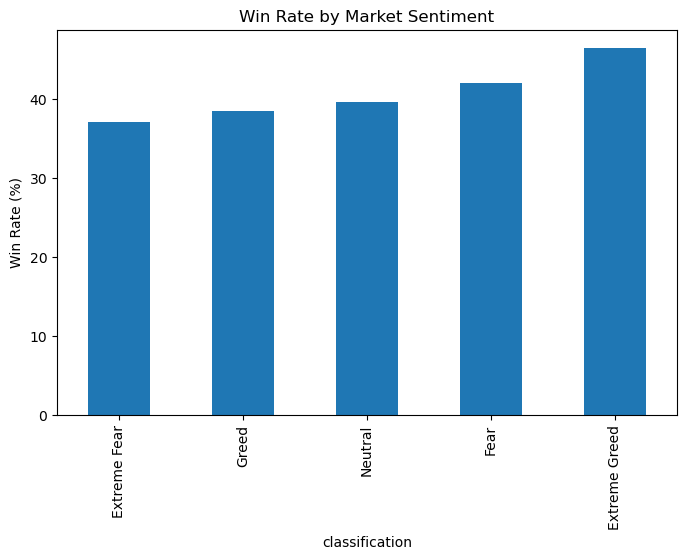

In [46]:
plt.figure(figsize=(8,5))

win_rate.sort_values().plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')

plt.show()

In [47]:
total_profit = merged.groupby(
    'classification'
)['Closed PnL'].sum()

print(total_profit)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [42]:
merged[['Closed PnL', 'win', 'abs_pnl']].head()

,Closed PnL,win,abs_pnl
0,0.0,False,0.0
1,0.0,False,0.0
2,0.0,False,0.0
3,0.0,False,0.0
4,0.0,False,0.0


In [49]:
print("Total Trades:", len(merged))
print("Total Traders:", merged['Account'].nunique())
print("Unique Coins:", merged['Coin'].nunique())

print("\nTotal PnL:")
print(merged['Closed PnL'].sum())

Total Trades: 211224
Total Traders: 32
Unique Coins: 246

Total PnL:
10296958.943436


In [50]:
win_rate = (
    merged.groupby('classification')['win']
    .mean()
    .mul(100)
    .round(2)
)

print(win_rate)

classification
Extreme Fear     37.06
Extreme Greed    46.49
Fear             42.08
Greed            38.48
Neutral          39.70
Name: win, dtype: float64


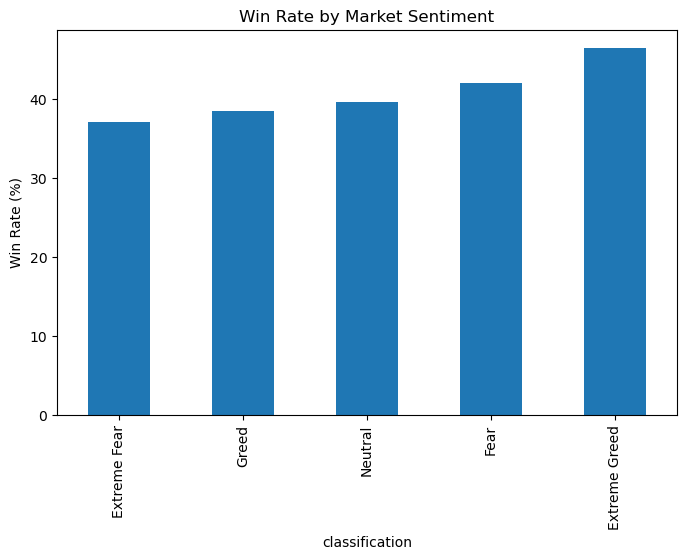

In [51]:
plt.figure(figsize=(8,5))

win_rate.sort_values().plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')

plt.show()

In [52]:
avg_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean().round(2)

print(avg_pnl)

classification
Extreme Fear     34.54
Extreme Greed    67.89
Fear             54.29
Greed            42.74
Neutral          34.31
Name: Closed PnL, dtype: float64


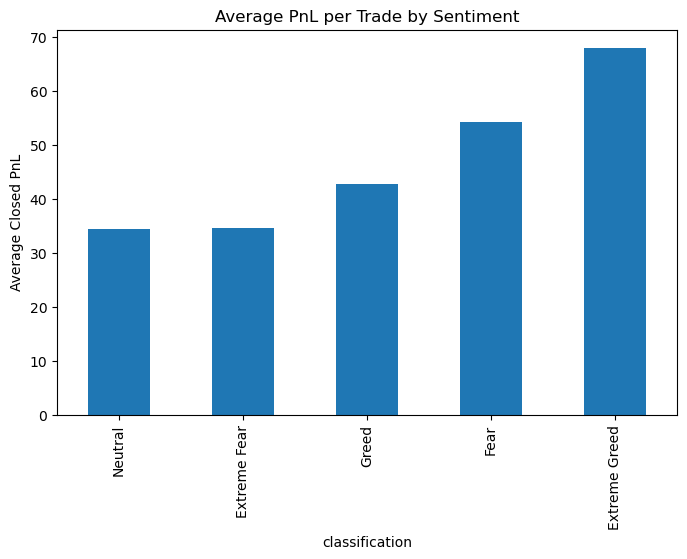

In [53]:
plt.figure(figsize=(8,5))

avg_pnl.sort_values().plot(kind='bar')

plt.title('Average PnL per Trade by Sentiment')
plt.ylabel('Average Closed PnL')

plt.show()

In [55]:
total_pnl = merged.groupby(
    'classification'
)['Closed PnL'].sum().round(2)

print(total_pnl)

classification
Extreme Fear      739110.25
Extreme Greed    2715171.31
Fear             3357155.44
Greed            2150129.27
Neutral          1292920.68
Name: Closed PnL, dtype: float64


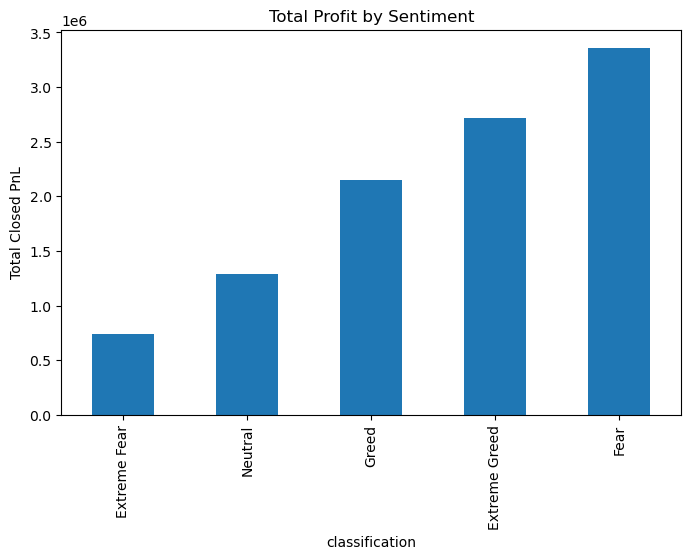

In [56]:
plt.figure(figsize=(8,5))

total_pnl.sort_values().plot(kind='bar')

plt.title('Total Profit by Sentiment')
plt.ylabel('Total Closed PnL')

plt.show()

In [57]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


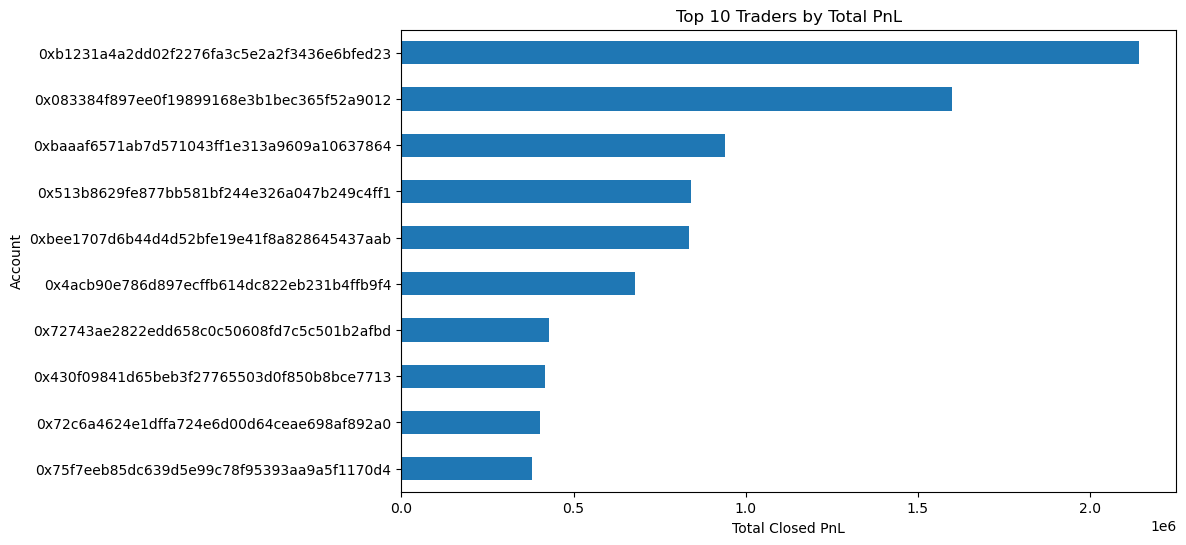

In [58]:
plt.figure(figsize=(10,6))

top_traders.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Traders by Total PnL')
plt.xlabel('Total Closed PnL')

plt.show()

# Statistical Analysis

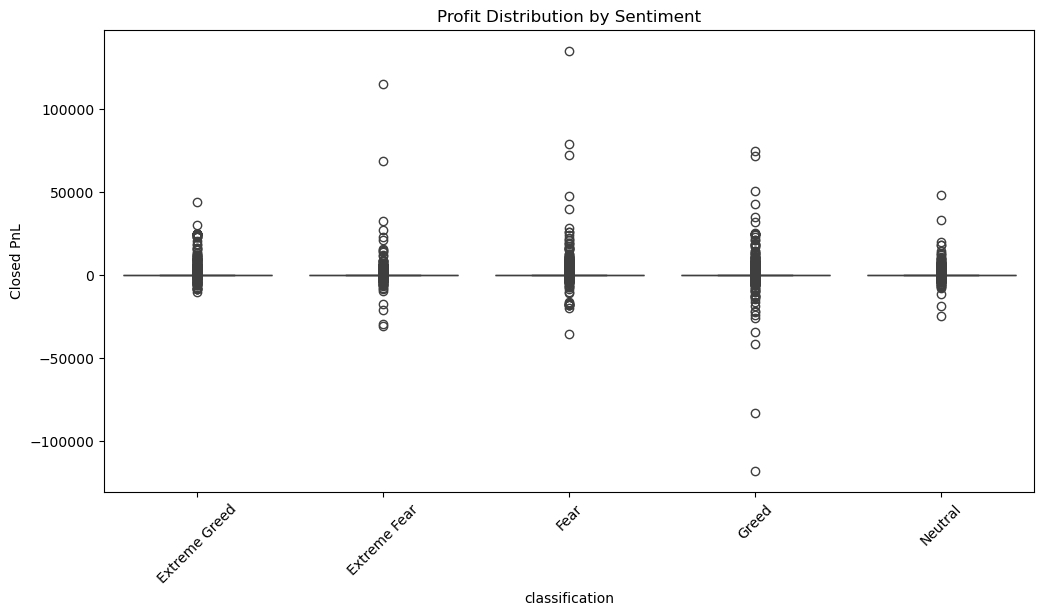

In [59]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title('Profit Distribution by Sentiment')
plt.xticks(rotation=45)

plt.show()

In [60]:
from scipy.stats import ttest_ind

fear = merged[
    merged['classification'] == 'Extreme Fear'
]['Closed PnL']

greed = merged[
    merged['classification'] == 'Extreme Greed'
]['Closed PnL']

t_stat, p_value = ttest_ind(
    fear,
    greed,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: -3.8511675429271293
P Value: 0.00011778426575866563


In [62]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'trade_date', 'timestamp', 'value', 'classification', 'date', 'win', 'abs_pnl']


# Trading Activity by Sentiment

In [63]:
trade_count = merged['classification'].value_counts()

print(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


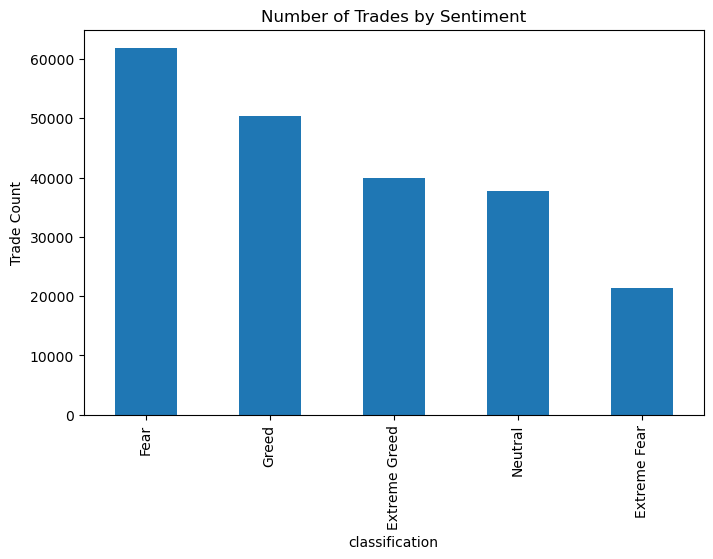

In [64]:
plt.figure(figsize=(8,5))

trade_count.plot(kind='bar')

plt.title('Number of Trades by Sentiment')
plt.ylabel('Trade Count')

plt.show()

In [65]:
avg_trade_size = merged.groupby(
    'classification'
)['Size USD'].mean().round(2)

print(avg_trade_size)

classification
Extreme Fear     5349.73
Extreme Greed    3112.25
Fear             7816.11
Greed            5736.88
Neutral          4782.73
Name: Size USD, dtype: float64


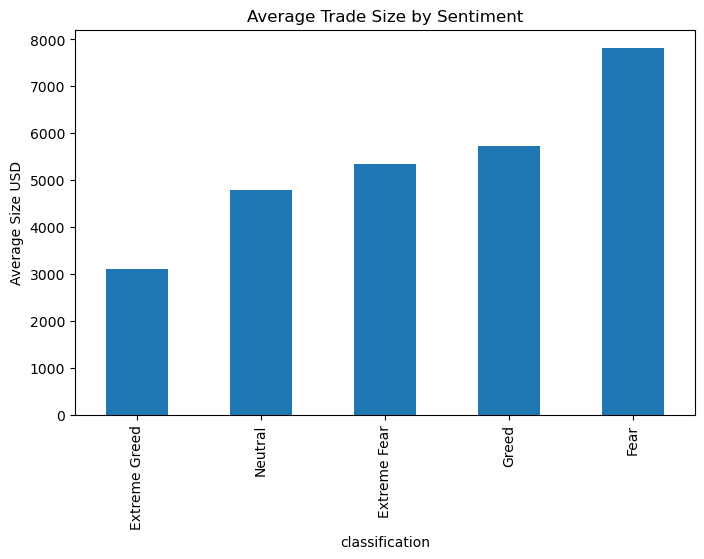

In [66]:
plt.figure(figsize=(8,5))

avg_trade_size.sort_values().plot(kind='bar')

plt.title('Average Trade Size by Sentiment')
plt.ylabel('Average Size USD')

plt.show()

In [67]:
top_coins = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

print(top_coins.head(15))

Coin
@107         2.783913e+06
HYPE         1.948485e+06
SOL          1.639556e+06
ETH          1.319979e+06
BTC          8.680447e+05
MELANIA      3.903511e+05
ENA          2.173295e+05
SUI          1.992688e+05
ZRO          1.837778e+05
DOGE         1.475432e+05
PURR/USDC    7.526106e+04
AIXBT        7.371217e+04
BERA         7.368975e+04
USUAL        6.963194e+04
EIGEN        6.503085e+04
Name: Closed PnL, dtype: float64


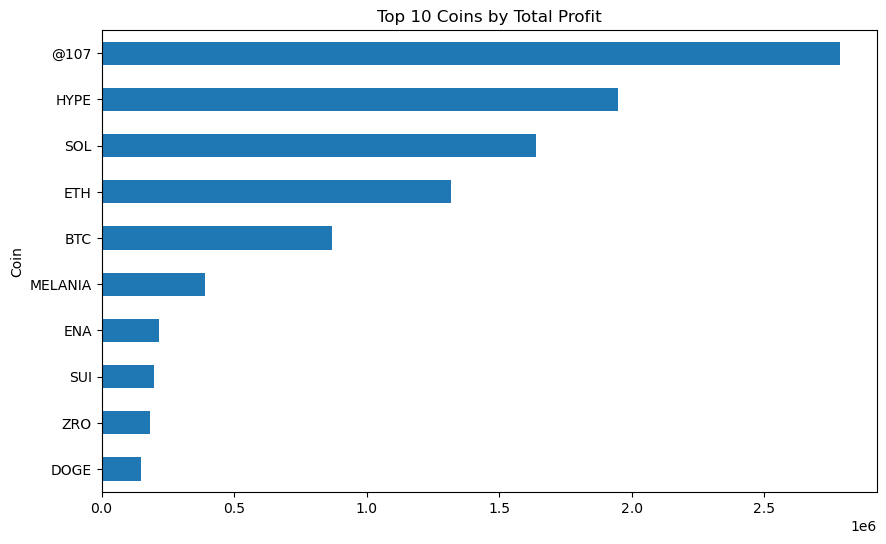

In [68]:
plt.figure(figsize=(10,6))

top_coins.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Coins by Total Profit')

plt.show()

In [69]:
summary_table = merged.groupby('classification').agg(
    Trades=('Closed PnL','count'),
    Avg_PnL=('Closed PnL','mean'),
    Total_PnL=('Closed PnL','sum'),
    Win_Rate=('win','mean')
)

summary_table['Win_Rate'] *= 100

summary_table = summary_table.round(2)

summary_table

,Trades,Avg_PnL,Total_PnL,Win_Rate
classification,,,,
Extreme Fear,21400,34.54,739110.25,37.06
Extreme Greed,39992,67.89,2715171.31,46.49
Fear,61837,54.29,3357155.44,42.08
Greed,50303,42.74,2150129.27,38.48
Neutral,37686,34.31,1292920.68,39.70


In [70]:
summary_table.to_csv(
    "sentiment_summary.csv"
)

In [71]:
['Size USD', 'Closed PnL']

['Size USD', 'Closed PnL']

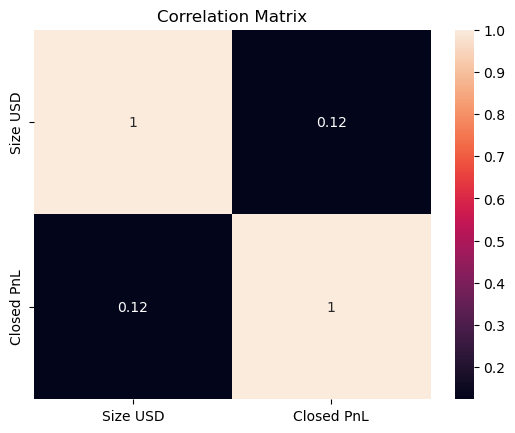

In [72]:
corr = merged[['Size USD', 'Closed PnL']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()